![](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)

# Clase 07: Transformer decoder y chat local

profesor [Carlos Daniel Jiménez](danieljimenez88m@gmail.com)


Esta notebook construye un mini modelo autoregresivo sobre el corpus local de `Las mil y una noches`. No intenta competir con un LLM moderno: busca mostrar por dentro los componentes que explican por que los Transformers reorganizaron el NLP.


In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F


from tools.notebook_utils import choose_value, configure_runtime
from tools.text_corpus import load_corpus_text

runtime = configure_runtime(seed=37)
print(runtime.summary())


seed=37 | smoke=False | online_mode=False | device=mps


## Por que un Transformer cambia el juego

Un decoder autoregresivo moderno combina tres ideas:

- embeddings para convertir tokens en vectores entrenables,
- informacion posicional para no perder el orden,
- self-attention causal para que cada token mire solo el pasado relevante.

La mascara causal es clave: evita que el modelo vea el futuro durante entrenamiento. Sin esa restriccion, el problema se volveria trivial y la generacion posterior no tendria sentido.


In [ ]:
base_text = load_corpus_text(separator='\n\n')
text = ((base_text + '\n\n') * int(choose_value(4, 3))).strip()
chars = sorted(set(text))
stoi = {ch: idx for idx, ch in enumerate(chars)}
itos = {idx: ch for ch, idx in stoi.items()}


def encode(value: str) -> list[int]:
    return [stoi[ch] for ch in value]


def decode(values: list[int]) -> str:
    return ''.join(itos[idx] for idx in values)


encoded = torch.tensor(encode(text), dtype=torch.long)
split = int(len(encoded) * 0.9)
train_ids = encoded[:split]
val_ids = encoded[split:]

context_size = int(choose_value(96, 64))
batch_size = int(choose_value(32, 16))

print({'characters': len(text), 'vocab_size': len(chars), 'context_size': context_size, 'batch_size': batch_size})
print(text[:500])


{'characters': 52306, 'vocab_size': 32, 'context_size': 96, 'batch_size': 32}
dicen los narradores antiguos que habia un rey poderoso que, herido por la traicion, habia jurado no confiar mas en ninguna mujer del reino. cada noche ordenaba que llevaran a su palacio a una joven distinta, y al amanecer la hacia apartar de su vista como si la noche no hubiera dejado memoria ni deber. la ciudad vivia en silencio; las madres escondian a sus hijas, los padres caminaban con la frente baja y los visires no se atrevan a contradecir la orden del soberano.

en la casa del gran visir 


In [ ]:
def get_batch(split_name: str) -> tuple[torch.Tensor, torch.Tensor]:
    source = train_ids if split_name == 'train' else val_ids
    starts = torch.randint(0, len(source) - context_size - 1, (batch_size,))
    x_batch = torch.stack([source[start : start + context_size] for start in starts])
    y_batch = torch.stack([source[start + 1 : start + context_size + 1] for start in starts])
    return x_batch.to(runtime.device), y_batch.to(runtime.device)


class TinyCausalTransformer(torch.nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 96,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.context_size = context_size
        self.token_embedding = torch.nn.Embedding(vocab_size, d_model)
        self.position_embedding = torch.nn.Embedding(context_size, d_model)
        layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = torch.nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = torch.nn.LayerNorm(d_model)
        self.head = torch.nn.Linear(d_model, vocab_size)

    def forward(
        self,
        idx: torch.Tensor,
        targets: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        _, steps = idx.shape
        positions = torch.arange(steps, device=idx.device)
        x_embed = self.token_embedding(idx) + self.position_embedding(positions)[None, :, :]
        mask = torch.full((steps, steps), float('-inf'), device=idx.device)
        mask = torch.triu(mask, diagonal=1)
        encoded_states = self.transformer(x_embed, mask=mask)
        logits = self.head(self.norm(encoded_states))

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1),
            )
        return logits, loss

    @torch.inference_mode()
    def generate(
        self,
        prompt: str,
        max_new_tokens: int = 120,
        temperature: float = 0.1,
        top_k: int | None = None,
        top_p: float | None = None,
    ) -> str:
        generated = torch.tensor([encode(prompt)], dtype=torch.long, device=runtime.device)
        for _ in range(max_new_tokens):
            idx_cond = generated[:, -self.context_size :]
            logits, _ = self(idx_cond)
            next_token_logits = logits[:, -1, :] / max(temperature, 1e-5)

            if top_k is not None:
                values, _ = torch.topk(
                    next_token_logits,
                    k=min(top_k, next_token_logits.shape[-1]),
                )
                cutoff = values[:, -1].unsqueeze(-1)
                next_token_logits = next_token_logits.masked_fill(
                    next_token_logits < cutoff,
                    float('-inf'),
                )

            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)
                sorted_probs = torch.softmax(sorted_logits, dim=-1)
                cumulative = torch.cumsum(sorted_probs, dim=-1)
                remove_mask = cumulative > top_p
                remove_mask[..., 1:] = remove_mask[..., :-1].clone()
                remove_mask[..., 0] = False
                sorted_logits = sorted_logits.masked_fill(remove_mask, float('-inf'))
                next_token_logits = torch.full_like(next_token_logits, float('-inf'))
                next_token_logits.scatter_(1, sorted_indices, sorted_logits)

            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_token], dim=1)
        return decode(generated[0].tolist())


model = TinyCausalTransformer(vocab_size=len(chars)).to(runtime.device)


/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_78862/3182800969.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = torch.nn.TransformerEncoder(layer, num_layers=n_layers)


Forma de la matriz PE: (96, 96)  (context_size x d_model)
Dimensiones pares: sin(), Dimensiones impares: cos()


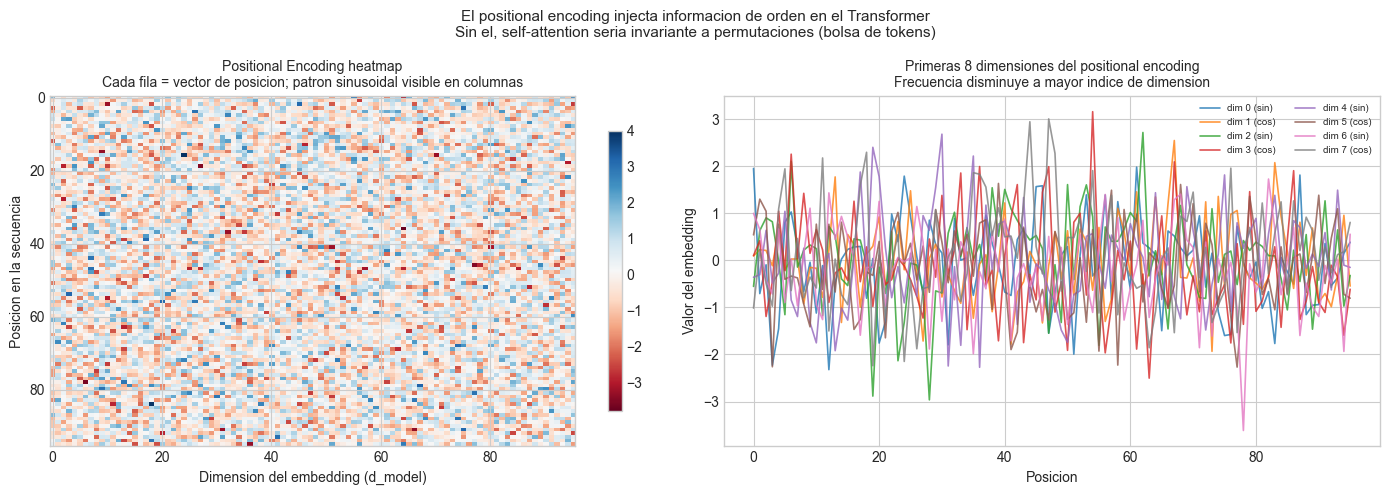

In [ ]:
# Positional encoding: heatmap del patron sinusoidal
import matplotlib.pyplot as plt
import numpy as np

# Extraer la matriz de embeddings posicionales del modelo
pe_weights = model.position_embedding.weight.detach().cpu().numpy()  # (context_size, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap 2D: posicion (eje Y) x dimension del embedding (eje X)
im = axes[0].imshow(pe_weights, cmap='RdBu', aspect='auto')
axes[0].set_xlabel('Dimension del embedding (d_model)')
axes[0].set_ylabel('Posicion en la secuencia')
axes[0].set_title(
    'Positional Encoding heatmap\n'
    'Cada fila = vector de posicion; patron sinusoidal visible en columnas',
    fontsize=10
)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Mostrar las primeras 8 dimensiones para ver sin/cos
positions = np.arange(pe_weights.shape[0])
for dim_idx in range(min(8, pe_weights.shape[1])):
    parity = 'sin' if dim_idx % 2 == 0 else 'cos'
    label = f'dim {dim_idx} ({parity})'
    axes[1].plot(positions, pe_weights[:, dim_idx], lw=1.2, alpha=0.8, label=label)
axes[1].set_xlabel('Posicion')
axes[1].set_ylabel('Valor del embedding')
axes[1].set_title(
    'Primeras 8 dimensiones del positional encoding\n'
    'Frecuencia disminuye a mayor indice de dimension',
    fontsize=10
)
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle(
    'El positional encoding injecta informacion de orden en el Transformer\n'
    'Sin el, self-attention seria invariante a permutaciones (bolsa de tokens)',
    fontsize=11
)
plt.tight_layout()
print(f'Forma de la matriz PE: {pe_weights.shape}  (context_size x d_model)')
print('Dimensiones pares: sin(), Dimensiones impares: cos()')


{'step': 1, 'train_loss': 2.228, 'val_loss': 2.231}
{'step': 100, 'train_loss': 2.187, 'val_loss': 2.176}
{'step': 200, 'train_loss': 2.191, 'val_loss': 2.179}
{'step': 300, 'train_loss': 2.171, 'val_loss': 2.161}
{'step': 320, 'train_loss': 2.153, 'val_loss': 2.143}


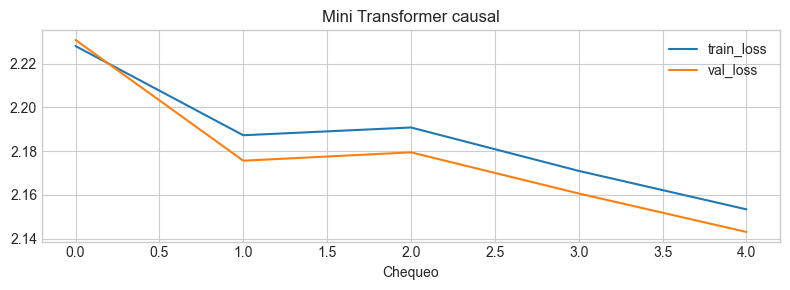

In [ ]:
steps = int(choose_value(320, 120))
eval_interval = int(choose_value(100, 30))
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
train_curve = []
val_curve = []

for step in range(1, steps + 1):
    model.train()
    xb, yb = get_batch('train')
    optimizer.zero_grad()
    _, loss = model(xb, yb)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % eval_interval == 0 or step == 1 or step == steps:
        model.eval()
        with torch.inference_mode():
            _, train_loss = model(*get_batch('train'))
            _, val_loss = model(*get_batch('val'))
        train_curve.append(float(train_loss.item()))
        val_curve.append(float(val_loss.item()))
        print({'step': step, 'train_loss': round(train_loss.item(), 3), 'val_loss': round(val_loss.item(), 3)})

plt.figure(figsize=(8, 3))
plt.plot(train_curve, label='train_loss')
plt.plot(val_curve, label='val_loss')
plt.title('Mini Transformer causal')
plt.xlabel('Chequeo')
plt.legend()
plt.tight_layout()



PROMPT: scheherezada dijo que 
greedy-like (top_k=1):
scheherezada dijo que e e en en en en e e e l en en en en co en co en el en con cia en enta enta en cona conta con denanan den den den den den
top-k:
scheherezada dijo que cialadon sir pancida e ele el posin sa en case en e erden din ladesona lomo. mis a ll ente eran e ena lorende anoredio e
top-p:
scheherezada dijo que vil pin co la vir cin a pra muco dadeselasuy e cian y l comanaranos eneza erela ranco u pre suado tas, da anco des donta

PROMPT: el rey observo el palacio y 
greedy-like (top_k=1):
el rey observo el palacio y de co de de de dere den den co de la de de la la la con de co den de den den den den den den co den co de den den den de
top-k:
el rey observo el palacio y do pla des as corerinoron pia prenadoronos curios a a pedinarala sin storo s cin des chion a cirden d de aro decoraladie
top-p:
el rey observo el palacio y lenardecosel rorormo fin coro tomo ablortrercintra ciondo la mo, abr en cidesio lerer deme fua mabrua

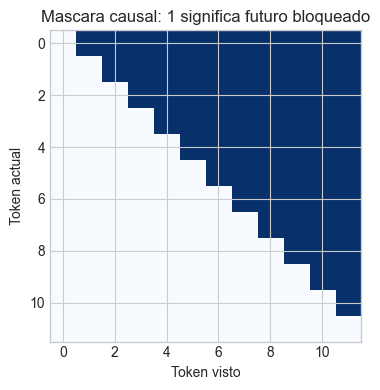

In [ ]:
mask_preview = torch.full((12, 12), float('-inf'))
mask_preview = torch.triu(mask_preview, diagonal=1)
plt.figure(figsize=(4, 4))
plt.imshow(mask_preview.eq(float('-inf')).cpu(), cmap='Blues')
plt.title('Mascara causal: 1 significa futuro bloqueado')
plt.xlabel('Token visto')
plt.ylabel('Token actual')
plt.tight_layout()

prompts = [
    'scheherezada dijo que ',
    'el rey observo el palacio y ',
    'cuando el mercader vio al genio ',
]
for prompt in prompts:
    print('\nPROMPT:', prompt)
    print('greedy-like (top_k=1):')
    print(model.generate(prompt, max_new_tokens=120, temperature=0.9, top_k=1))
    print('top-k:')
    print(model.generate(prompt, max_new_tokens=120, temperature=0.95, top_k=8))
    print('top-p:')
    print(model.generate(prompt, max_new_tokens=120, temperature=0.95, top_p=0.9))


Ejemplo:
  Token en posicion 3 puede ver: posiciones 0, 1, 2, 3
  Token en posicion 3 NO puede ver: posiciones 4, 5, 6...
  Esto hace coherente el entrenamiento autoregresivo:
  el modelo nunca ve el token que tiene que predecir


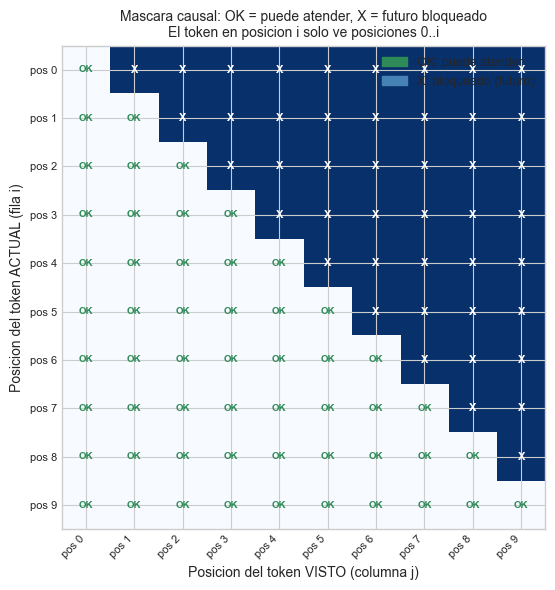

In [ ]:
# Mascara causal con anotaciones explicativas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

SIZE = 10
mask_matrix = np.zeros((SIZE, SIZE))
for i in range(SIZE):
    for j in range(SIZE):
        mask_matrix[i, j] = 1 if j > i else 0  # 1 = bloqueado (futuro)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(mask_matrix, cmap='Blues', vmin=0, vmax=1)

# Anotar con numeros de posicion en la diagonal
for i in range(SIZE):
    for j in range(SIZE):
        if j <= i:
            ax.text(j, i, 'OK', ha='center', va='center', fontsize=7,
                    color='seagreen', fontweight='bold')
        else:
            ax.text(j, i, 'X', ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')

ax.set_xlabel('Posicion del token VISTO (columna j)', fontsize=10)
ax.set_ylabel('Posicion del token ACTUAL (fila i)', fontsize=10)
ax.set_title(
    'Mascara causal: OK = puede atender, X = futuro bloqueado\n'
    'El token en posicion i solo ve posiciones 0..i',
    fontsize=10
)
ax.set_xticks(range(SIZE))
ax.set_yticks(range(SIZE))
ax.set_xticklabels([f'pos {j}' for j in range(SIZE)], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f'pos {i}' for i in range(SIZE)], fontsize=8)

# Ejemplo textual en el titulo
ok_patch = mpatches.Patch(color='seagreen', label='OK: puede atender')
x_patch = mpatches.Patch(color='steelblue', label='X: bloqueado (futuro)')
ax.legend(handles=[ok_patch, x_patch], loc='upper right', fontsize=9)

plt.tight_layout()
print('Ejemplo:')
print('  Token en posicion 3 puede ver: posiciones 0, 1, 2, 3')
print('  Token en posicion 3 NO puede ver: posiciones 4, 5, 6...')
print('  Esto hace coherente el entrenamiento autoregresivo:')
print('  el modelo nunca ve el token que tiene que predecir')


In [ ]:
if runtime.online_mode:
    from transformers import pipeline

    narrator = pipeline('text2text-generation', model='google/flan-t5-small')
    context = base_text[:900]
    prompt = (
        'Responde en espanol, con tono narrativo y claro. '
        'Usa el siguiente contexto como apoyo, sin inventar personajes nuevos.\n\n'
        f'Contexto:\n{context}\n\n'
        'Pregunta: Que aprende el rey cuando escucha relatos noche tras noche?\n'
        'Respuesta:'
    )
    response = narrator(
        prompt,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
    )[0]['generated_text']
    print(response)
else:
    print(
        'HENRY_DL_ONLINE_MODE=0 -> la comparacion con un modelo preentrenado queda desactivada.'
    )


HENRY_DL_ONLINE_MODE=0 -> la comparacion con un modelo preentrenado queda desactivada.


## Para cerrar

### Lo esencial

- el embedding posiciona tokens en un espacio entrenable,
- la informacion posicional evita que el orden desaparezca,
- la mascara causal vuelve coherente el entrenamiento autoregresivo,
- el decoding cambia mucho la salida aunque el modelo sea el mismo.

### Lectura critica

Un mini Transformer local ayuda a entender el mecanismo, pero no reemplaza un modelo base moderno entrenado con mas datos y compute. Justamente por eso conviene tener ambas cosas en clase: comprension mecanica y comparacion con una referencia mas fuerte.
